# Inter-Subset Analysis

This notebook loads a benchmark benchmark with pre-defined subsets and analyzes the differences between:

1. Model ranking on the full benchmark vs each subset
2. Model performance on the full benchmark vs each subset

## Set Up

Import packages.

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import kendalltau, rankdata
from tqdm import tqdm
from src.utils.enums import Dataset
from src.utils.data import (
    get_metadata_mask,
    get_unique_metadata_values,
    load_dataset,
)
from src.utils.model import load_model_scores
from src.utils.path import build_plot_path
from src.utils.plot import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Specify the benchmark to analyze, and load its dataset and model scores.

In [16]:
dataset = Dataset.DS_1000
dataset_df = load_dataset(dataset)
model_scores_df = load_model_scores(dataset)
models = model_scores_df.columns.tolist()

print(f"Number of instances: {(num_instances := len(dataset_df))}")
display(dataset_df.head())
print("-" * 200)
print(f"Number of models: {(num_models := len(models))}")
display(model_scores_df.head())

assert len(dataset_df) == len(model_scores_df)

Number of instances: 1000


,prompt,reference_code,metadata,code_context
0,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n return df.iloc[List]\n\n...","{'problem_id': 0, 'library_problem_id': 0, 'li...",import pandas as pd\nimport numpy as np\nimpor...
1,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n df2 = df.iloc[List].rein...","{'problem_id': 1, 'library_problem_id': 1, 'li...",import pandas as pd\nimport numpy as np\nimpor...
2,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 2, 'library_problem_id': 2, 'li...",import pandas as pd\nimport numpy as np\nimpor...
3,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 3, 'library_problem_id': 3, 'li...",import pandas as pd\nimport numpy as np\nimpor...
4,Problem:\nI have following pandas dataframe :\...,result = df.where(df.apply(lambda x: x.map...,"{'problem_id': 4, 'library_problem_id': 4, 'li...",import pandas as pd\nimport numpy as np\nimpor...


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of models: 3


,deepseek-coder-6.7b-base,gpt-3.5-turbo-0613,gpt-4o-2024-08-06
0,1,0,0
1,0,1,1
2,1,0,1
3,1,1,1
4,0,1,0


## Analyses

### Model Ranking Analysis

Count the number of subsets where the local model ranking differs from the global model ranking.

In [17]:
global_scores = model_scores_df.mean()
global_ranking = rankdata(global_scores)

num_different = 0

subset_col = dataset.subset_col
is_ds_1000 = dataset == Dataset.DS_1000
subsets = (
    get_unique_metadata_values(dataset_df, subset_col)
    if is_ds_1000
    else dataset_df[subset_col].unique()
)

for subset in subsets:
    mask = (
        get_metadata_mask(dataset_df, subset_col, subset)
        if is_ds_1000
        else dataset_df[subset_col] == subset
    )
    subset_scores = model_scores_df[mask].mean()
    subset_ranking = rankdata(subset_scores)
    different_ranking = not np.array_equal(subset_ranking, global_ranking)
    num_different += 1 if different_ranking else 0

plural = "libraries" if is_ds_1000 else f"{subset_col}s"
print(f"{(plural)}: {subsets}")
print(
    f"Total {plural}: {(num_subsets := len(subsets))}. "
    f"{plural.capitalize()} that differ from global ranking: {num_different}"
)

libraries: {'Scipy', 'Pytorch', 'Numpy', 'Matplotlib', 'Pandas', 'Sklearn', 'Tensorflow'}
Total libraries: 7. Libraries that differ from global ranking: 1


Compute the Kendall's Tau between each subset's local model ranking and the global model ranking. 

In [18]:
kwargs = {
    "desc": "Computing Kendall's taus",
    "total": num_subsets,
    "unit": "subset",
}

kendall_tau_results = []

for subset in tqdm(subsets, **kwargs):
    mask = (
        get_metadata_mask(dataset_df, subset_col, subset)
        if is_ds_1000
        else dataset_df[subset_col] == subset
    )
    subset_scores = model_scores_df[mask].mean()
    kendall_tau, _ = kendalltau(global_scores, subset_scores)
    kendall_tau_results.append(
        {
            "subset": subset,
            "scores": subset_scores,
            "kendall_tau": kendall_tau,
            "num_instances": len(model_scores_df[mask]),
        }
    )

kendall_tau_df = pd.DataFrame(kendall_tau_results)

Computing Kendall's taus: 100%|██████████| 7/7 [00:00<00:00, 777.63subset/s]


Plot the distribution of Kendall's Taus between each subset's local model ranking and the global model ranking.

Saved plot to C:\Users\Mike\vscode\EvalTree\results\plots\inter_subset_analysis\DS-1000\kendall_tau_distribution-subset_col=library.png


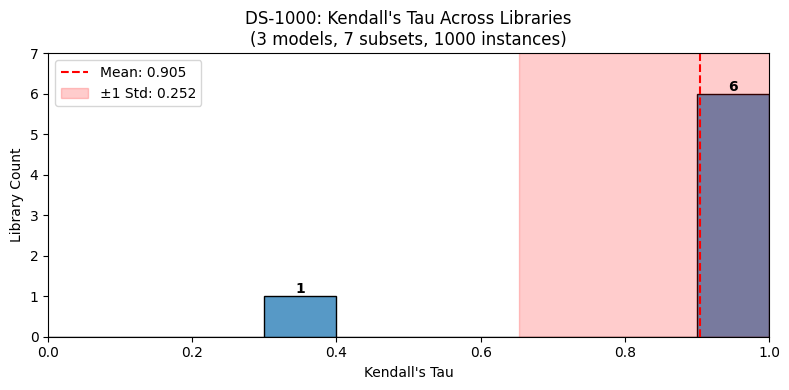

In [ ]:
num_models = len(model_scores_df.columns)
num_instances = len(dataset_df)

xlim = (-1, 1) if min(kendall_tau_df["kendall_tau"]) < 0 else (0, 1)

ylim = {
    Dataset.DS_1000: (0, num_subsets),
    Dataset.MATH: (0, num_subsets),
    Dataset.MMLU: (0, num_subsets // 2),
}[dataset]

plot_histogram(
    kendall_tau_df["kendall_tau"],
    xlabel="Kendall's Tau",
    ylabel=f"{subset_col.capitalize()} Count",
    title=(
        f"{dataset}: Kendall's Tau Across {plural.capitalize()}"
        f"\n({num_models} models, {num_subsets} subsets, {num_instances} instances)"
    ),
    annotate=True,
    mean=kendall_tau_df["kendall_tau"].mean(),
    std=kendall_tau_df["kendall_tau"].std(),
    xlim=xlim,
    ylim=ylim,
)

analysis = "inter_subset_analysis"
plot_name = "kendall-tau_histogram"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
print(f"Saved plot to {file_path}")
plt.show()

### Model Performance Analysis

Compute each subset's mean model scores.

In [20]:
subset_to_scores = {}
for subset in subsets:
    mask = (
        get_metadata_mask(dataset_df, subset_col, subset)
        if is_ds_1000
        else dataset_df[subset_col] == subset
    )
    subset_to_scores[subset] = model_scores_df[mask].mean()
subset_scores_df = pd.DataFrame(subset_to_scores).T
subset_scores_df.index.name = "subset"

Plot the distribution of each model's mean performance across the different subsets.

Saved plot to C:\Users\Mike\vscode\EvalTree\results\plots\inter_subset_analysis\DS-1000\accuracy_distribution-subset_col=library.png


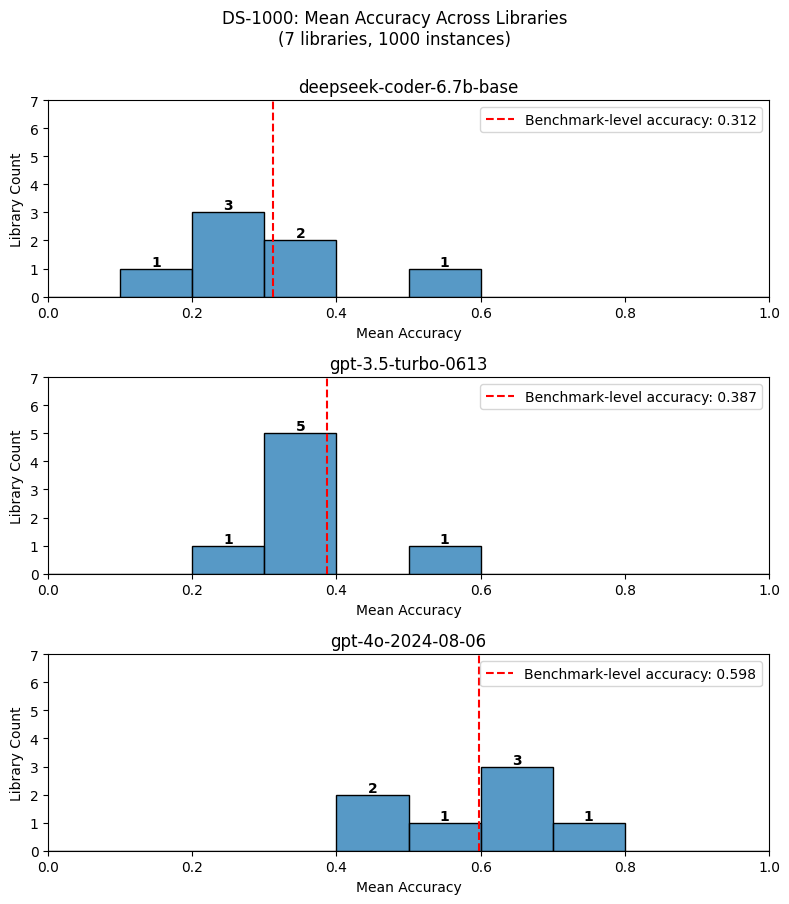

In [ ]:
_, axes = plt.subplots(num_models, 1, figsize=(8, 3 * num_models))

xlim = {
    Dataset.DS_1000: (0, 1),
    Dataset.MATH: (0, 1),
    Dataset.MMLU: (0, 1),
}[dataset]

ylim = {
    Dataset.DS_1000: (0, num_subsets),
    Dataset.MATH: (0, num_subsets),
    Dataset.MMLU: (0, num_subsets // 2),
}[dataset]

metric = Dataset(dataset).metric

for i, model in enumerate(subset_scores_df.columns):
    plot_histogram(
        subset_scores_df[model],
        xlabel=f"Mean {metric.title()}",
        ylabel=f"{subset_col.capitalize()} Count",
        title=f"{model}",
        ax=axes[i] if num_models > 1 else axes,
        annotate=True,
        mean=global_scores[model],
        mean_label=f"Benchmark-level {metric}",
        xlim=xlim,
        ylim=ylim,
    )

plt.suptitle(
    f"{dataset}: Mean {metric.title()} Across {plural.capitalize()}"
    f"\n({num_subsets} {plural}, {num_instances} instances)",
    y=1.0,
)
plt.tight_layout()
plot_name = "performance_histogram"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
print(f"Saved plot to {file_path}")
plt.show()